In [2]:
from data import load_mri_dataframe, get_dataloaders, get_dataloader_binarytransformed
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from train_generalized_earlystopping import train, dice_loss, bce_loss, bce_dice_loss
from eval import evaluate, evaluate_losses, evaluate_classification
from hyperparameter_search import create_study
from BaselineUNet import BaselineUNet
from OriginalUNet import OriginalUNet
import torch.optim as optim
from ImprovedUNet import ImprovedUNet
import json

In [3]:
df = load_mri_dataframe()

In [4]:
# Load all results
with open("best_params.json", "r") as f:
    all_results = json.load(f)

# Filter for augment=True and model_type="improved"
selected_sudies = [entry for entry in all_results if entry.get("augment") is True and entry.get("model_type") == "improved"]


# Select the one with the highest n_trials
best_study_aug_improved = max(selected_sudies, key=lambda x: x.get("n_trials", 0))

params_aug_improved = best_study_aug_improved["params"]
print("Best params:", params_aug_improved)
print("n_trials:", best_study_aug_improved["n_trials"])
print("Best Dice Score:", best_study_aug_improved["dice_val/acc"])



Best params: {'lr': 0.00022062884670065198, 'batch_size': 4, 'optimizer': 'Adam', 'step_size': 7, 'gamma': 0.49939353507708156, 'num_layers': 4, 'num_filters': 32}
n_trials: 30
Best Dice Score: 0.8199046555222297


[Data] Train images: 1167 ; Val images: 206


Final Test Dice: 0.8184
Final Test IoU : 0.7399


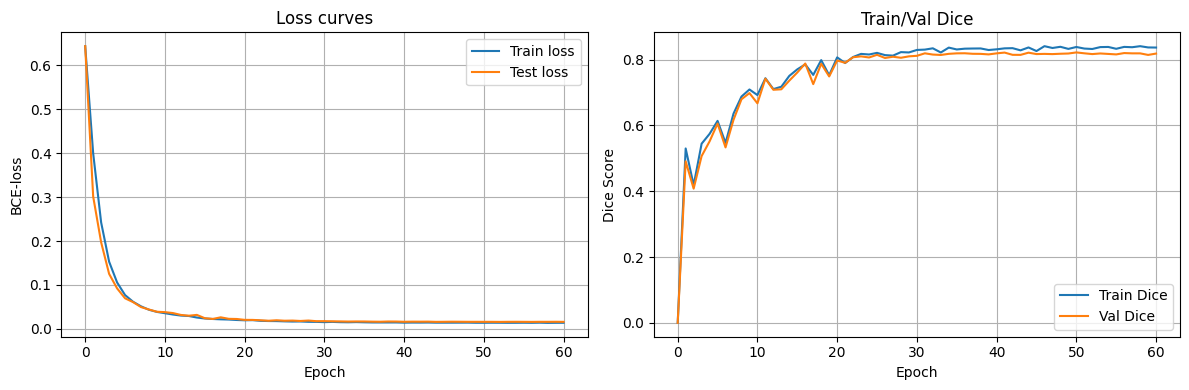

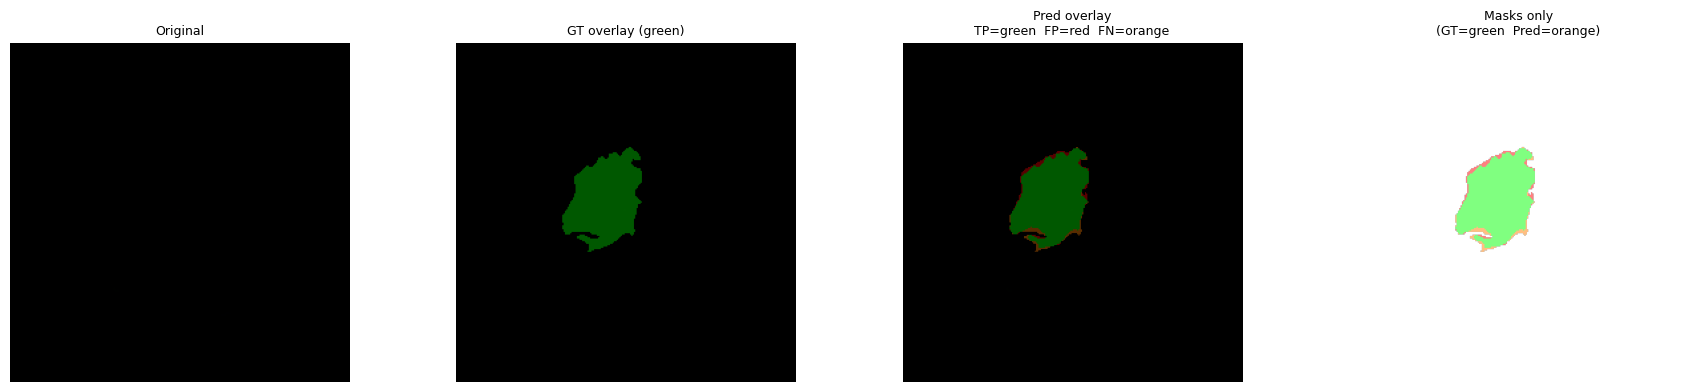

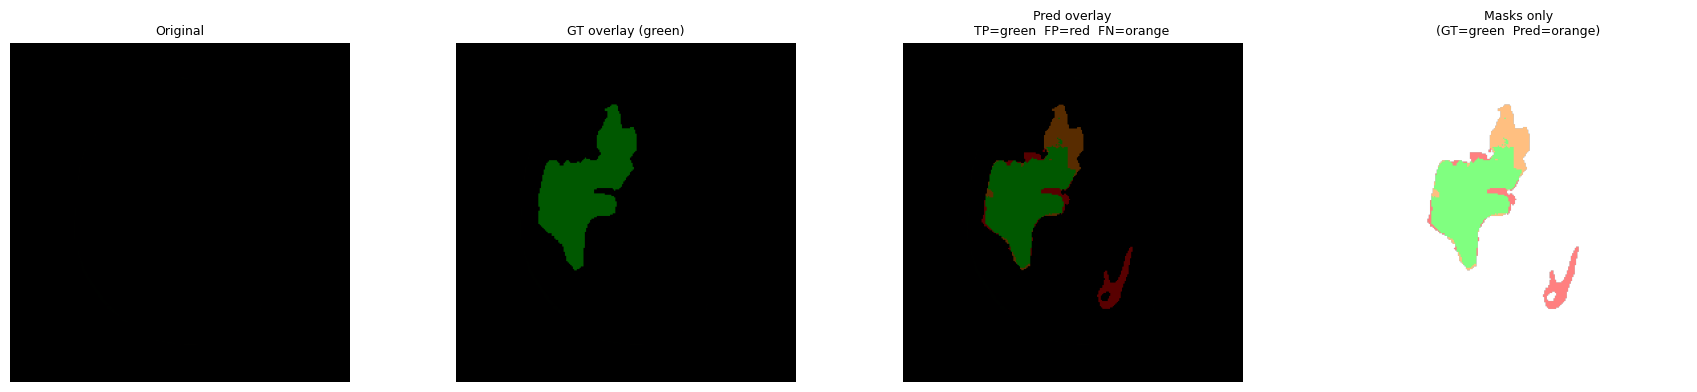

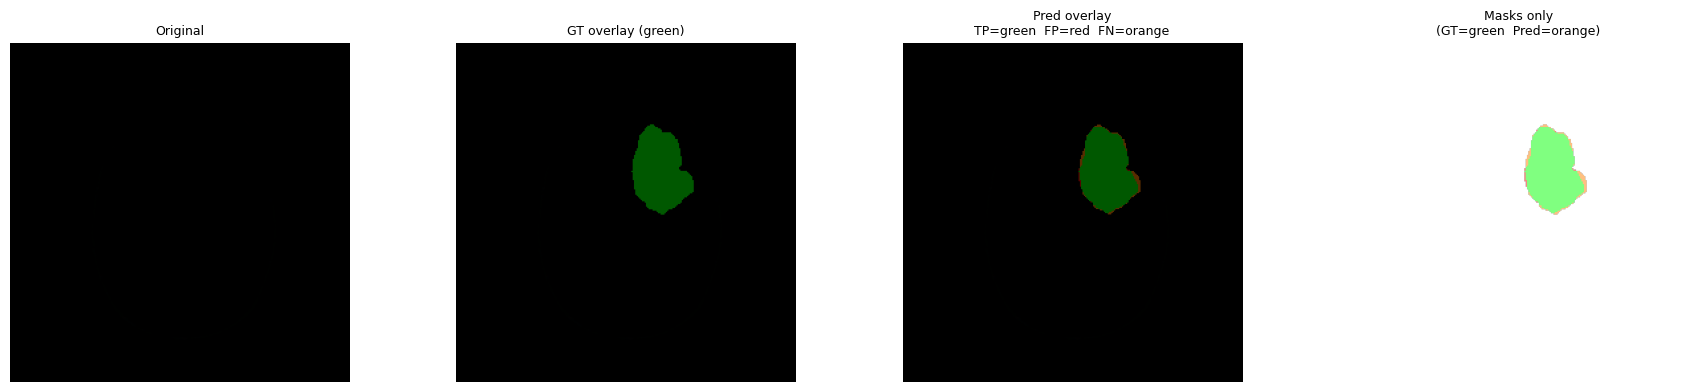

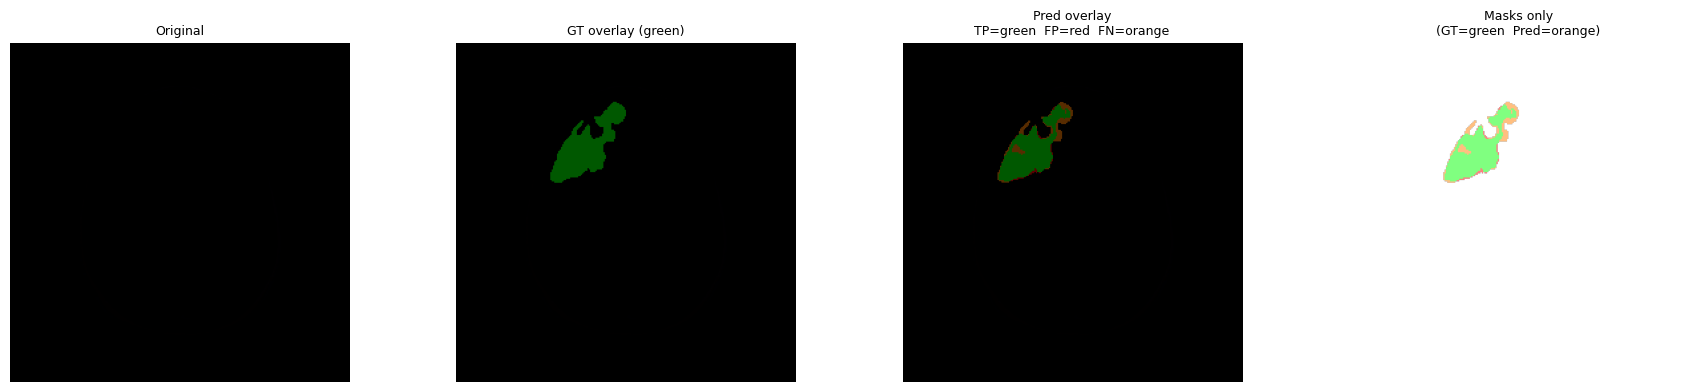

In [ ]:
# Run training with the loaded parameters
device = torch.device('cuda')

train_loader_aug, val_loader_aug = get_dataloaders(df, val_split=0.15, batch_size=params_aug_improved["batch_size"], omit_empty_masks=True, augment=True)

model_aug_improved = ImprovedUNet(num_layers=params_aug_improved['num_layers'], num_filters=params_aug_improved['num_filters'])
print("Number of Parameters (Improved UNet, augment):", sum(p.numel() for p in model_aug_improved.parameters()))
trained_model_aug_improved_bce, results_aug_improved_bce = train(
    model_aug_improved,
    train_loader_aug,
    val_loader_aug,
    device,
    lr=params_aug_improved['lr'],
    optimizer_class=optim.Adam if params_aug_improved['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_aug_improved['step_size'], "gamma": params_aug_improved['gamma']},
    early_stopping=False
)
evaluate(results_aug_improved_bce)

In [ ]:
selected_sudies_noaug_improved = [entry for entry in all_results if entry.get("augment") is False and entry.get("model_type") == "improved"]

# Select the one with the highest n_trials
best_study_noaug_improved = max(selected_sudies_noaug_improved, key=lambda x: x.get("n_trials", 0))

params_noaug_improved = best_study_aug_improved["params"]
print("Best params:", params_noaug_improved)
print("n_trials:", best_study_noaug_improved["n_trials"])
print("Best Dice Score:", best_study_noaug_improved["dice_val/acc"])

Best params: {'lr': 0.00022062884670065198, 'batch_size': 4, 'optimizer': 'Adam', 'step_size': 7, 'gamma': 0.49939353507708156, 'num_layers': 4, 'num_filters': 32}
n_trials: 30
Best Dice Score: 0.8018970467200895


[Data] Train images: 1167 ; Val images: 206


Final Test Dice: 0.8390
Final Test IoU : 0.7603


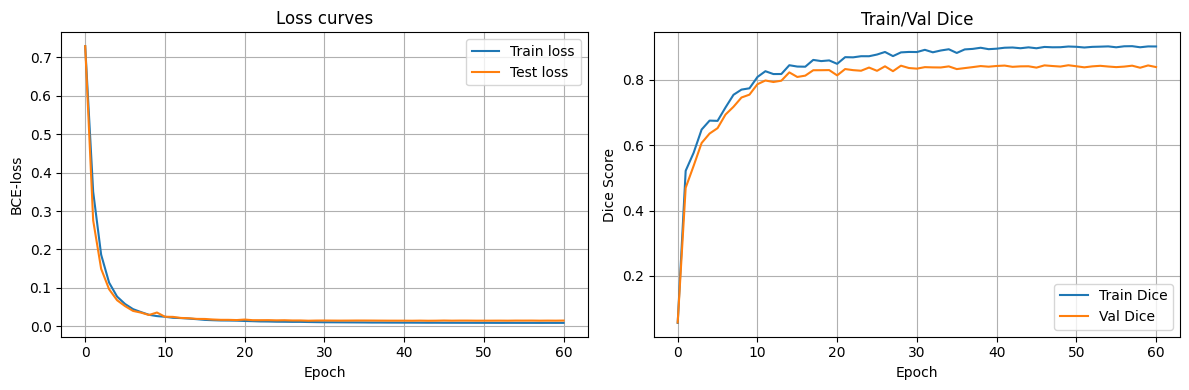

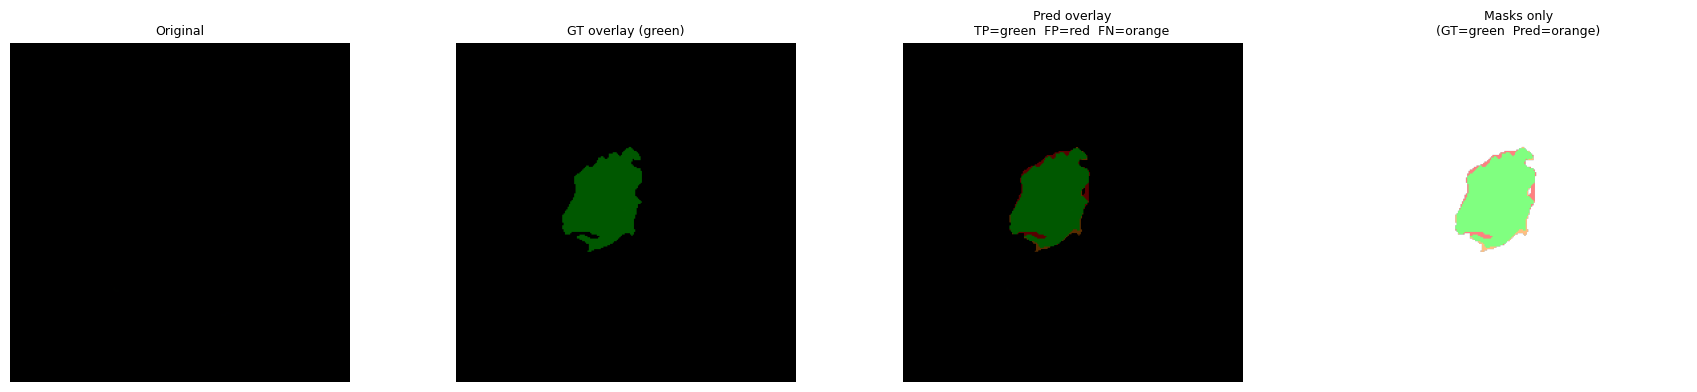

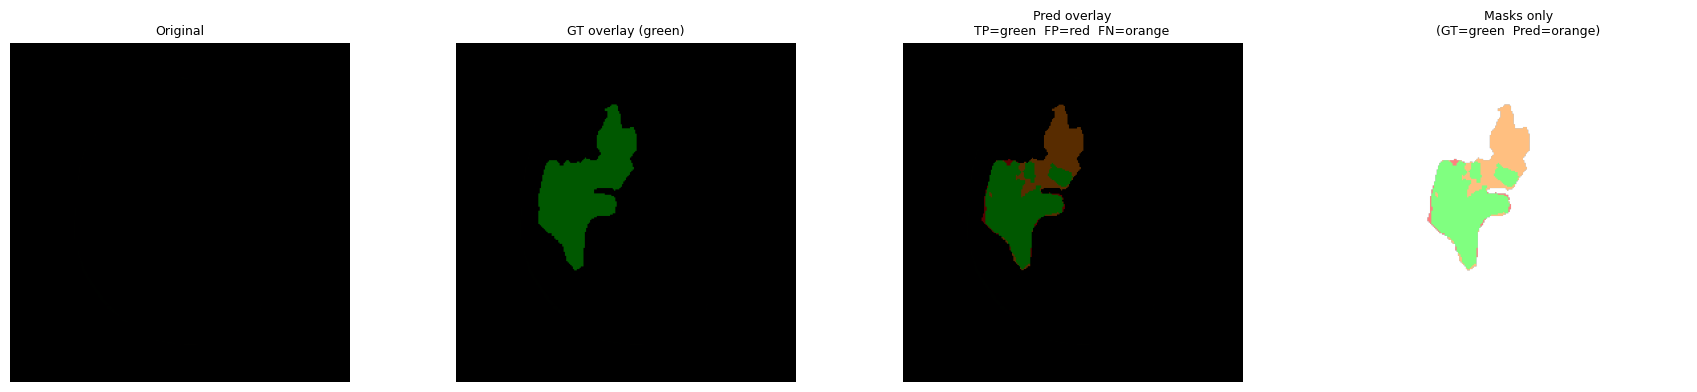

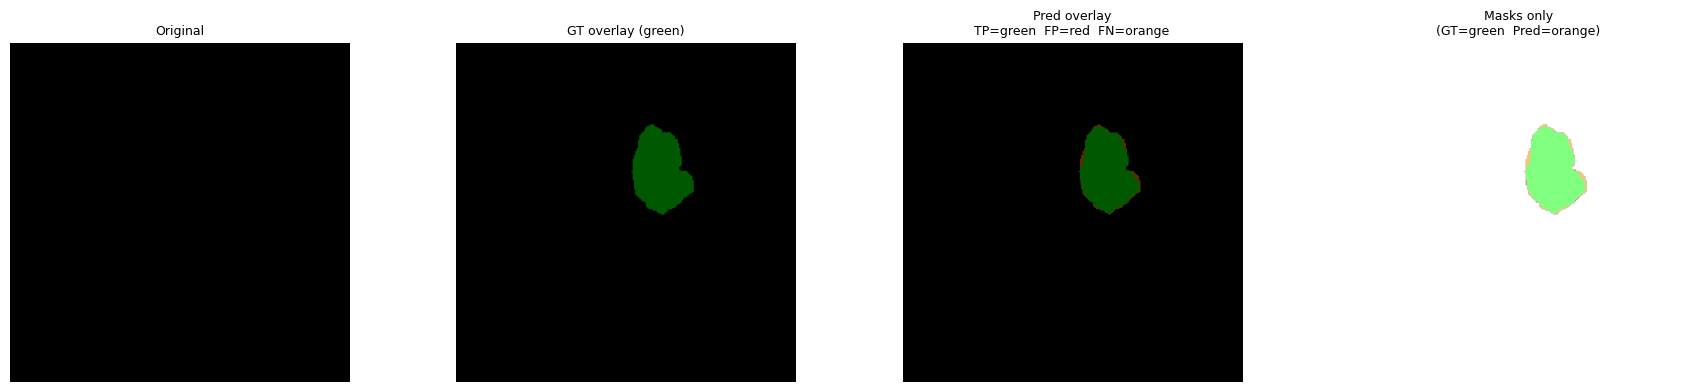

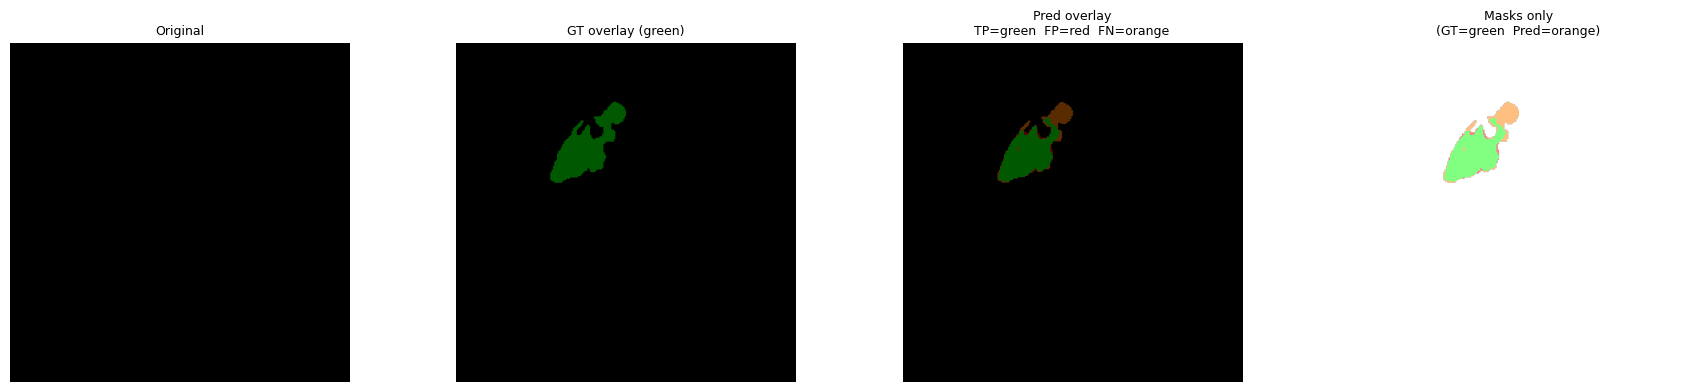

In [ ]:
# Run training with the loaded parameters
device = torch.device('cuda')

train_loader_noaug, val_loader_noaug = get_dataloaders(df, val_split=0.15, batch_size=params_noaug_improved["batch_size"], omit_empty_masks=True, augment=False)

model_noaug_improved = ImprovedUNet(num_layers=params_noaug_improved['num_layers'], num_filters=params_noaug_improved['num_filters'])
print("Number of Parameters (Improved UNet, no augment):", sum(p.numel() for p in model_noaug_improved.parameters()))
trained_model_noaug_improved_bce, results_noaug_improved_bce = train(
    model_noaug_improved,
    train_loader_noaug,
    val_loader_noaug,
    device,
    lr=params_noaug_improved['lr'],
    optimizer_class=optim.Adam if params_noaug_improved['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_noaug_improved['step_size'], "gamma": params_noaug_improved['gamma']},
    early_stopping=False
)
evaluate(results_noaug_improved_bce)

In [ ]:
selected_sudies_noaug_baseline = [entry for entry in all_results if entry.get("augment") is False and entry.get("model_type") == "baseline"]

# Select the one with the highest n_trials
best_study_noaug_baseline = max(selected_sudies_noaug_baseline, key=lambda x: x.get("n_trials", 0))

params_noaug_baseline = best_study_noaug_baseline["params"]
print("Best params:", params_noaug_baseline)
print("n_trials:", best_study_noaug_baseline["n_trials"])
print("Best Dice Score:", best_study_noaug_baseline["dice_val/acc"])

Best params: {'lr': 0.00611982566985783, 'batch_size': 8, 'optimizer': 'Adam', 'step_size': 7, 'gamma': 0.41842218664003056}
n_trials: 30
Best Dice Score: 0.5664017993171199


[Data] Train images: 1167 ; Val images: 206


Final Test Dice: 0.5286
Final Test IoU : 0.4372


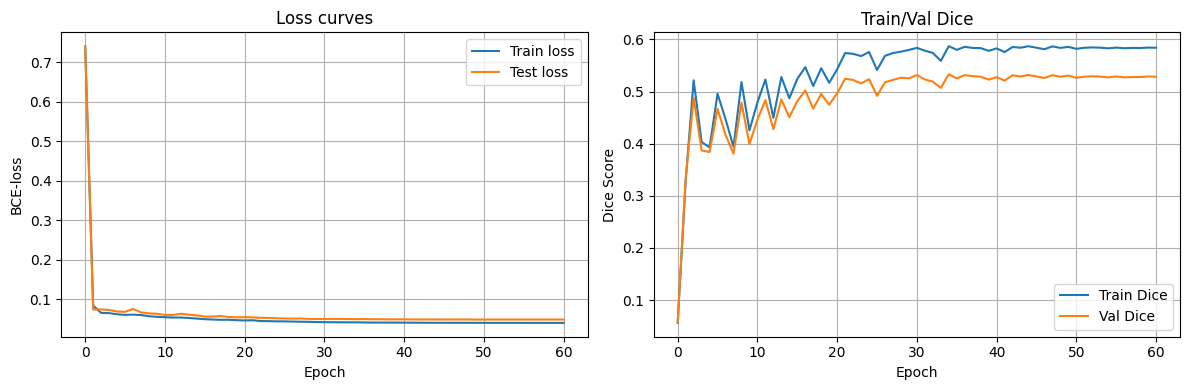

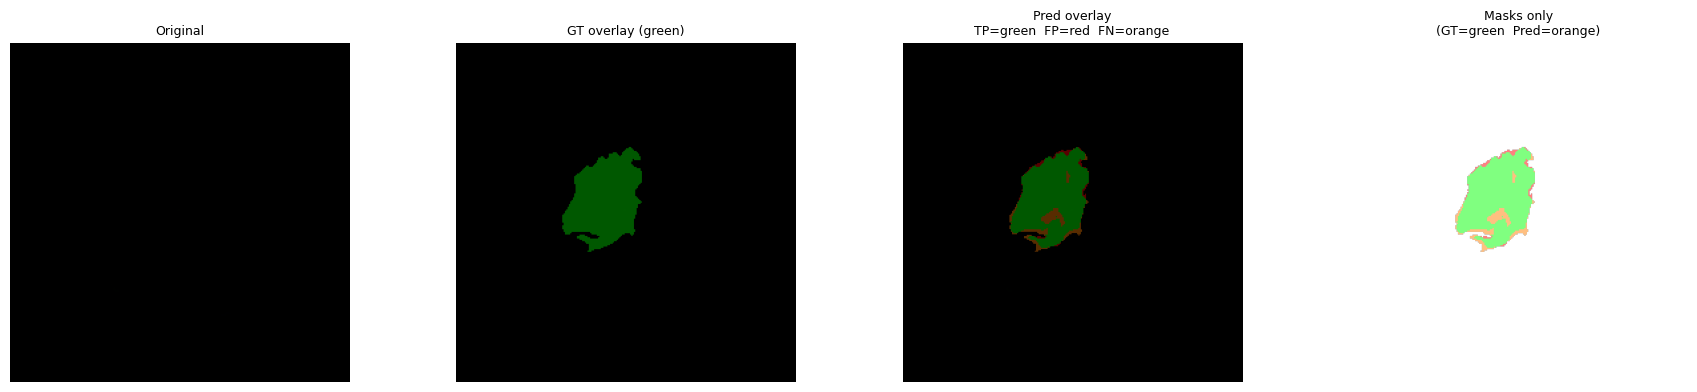

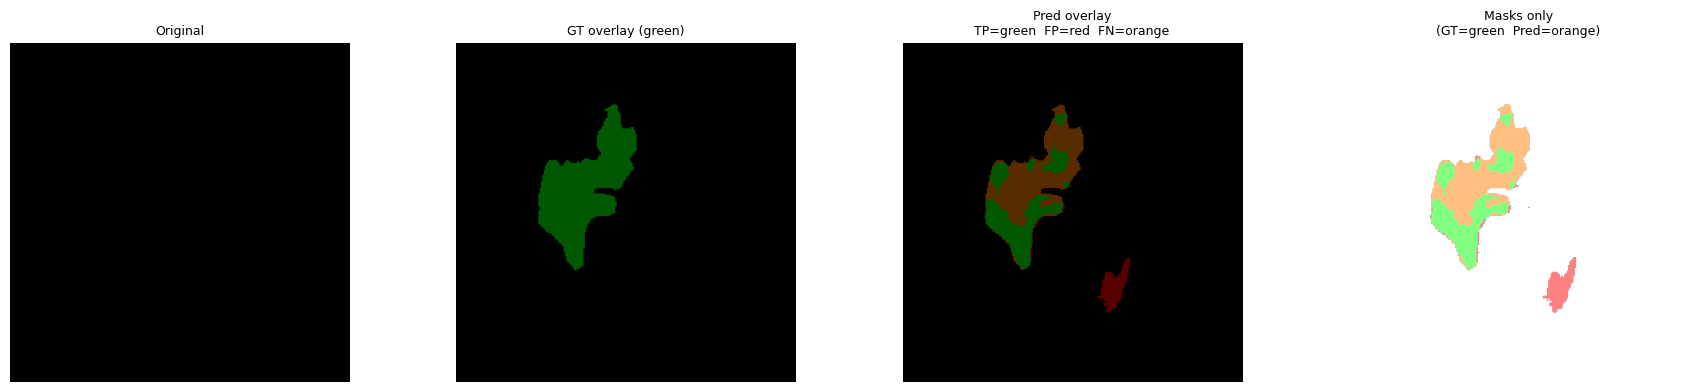

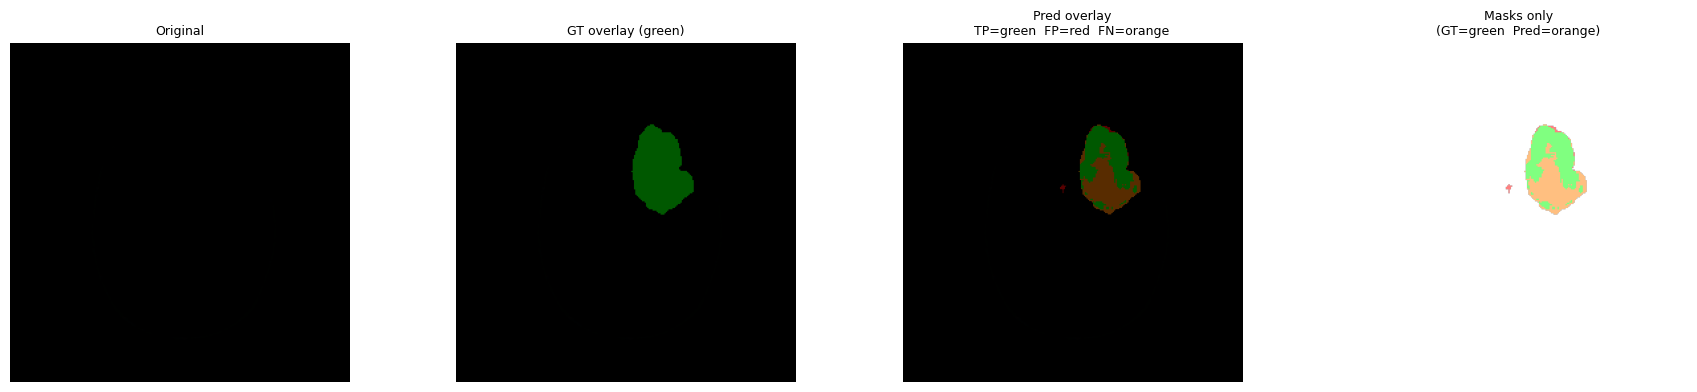

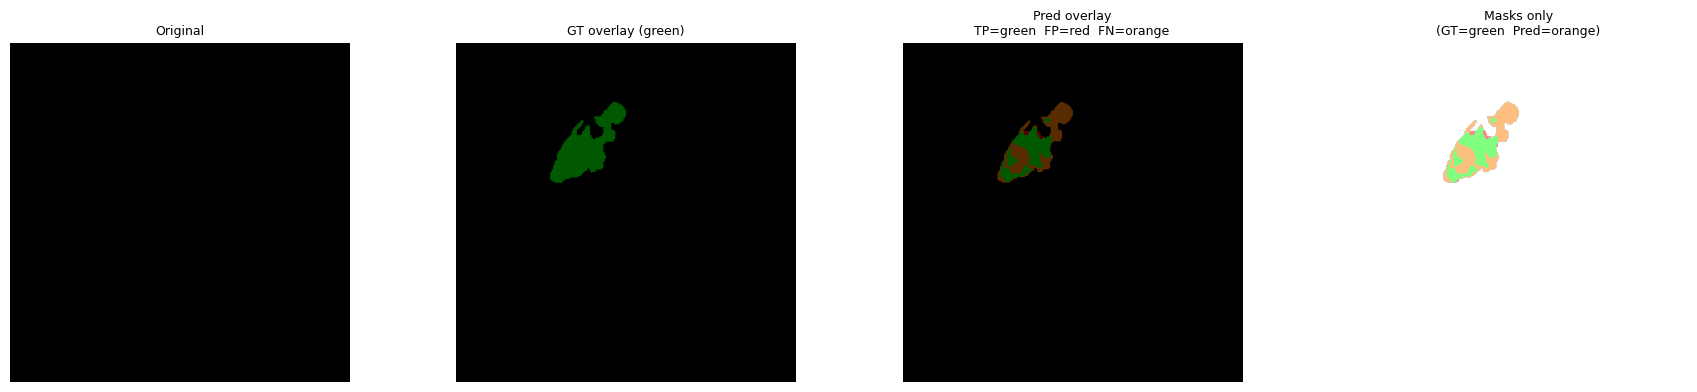

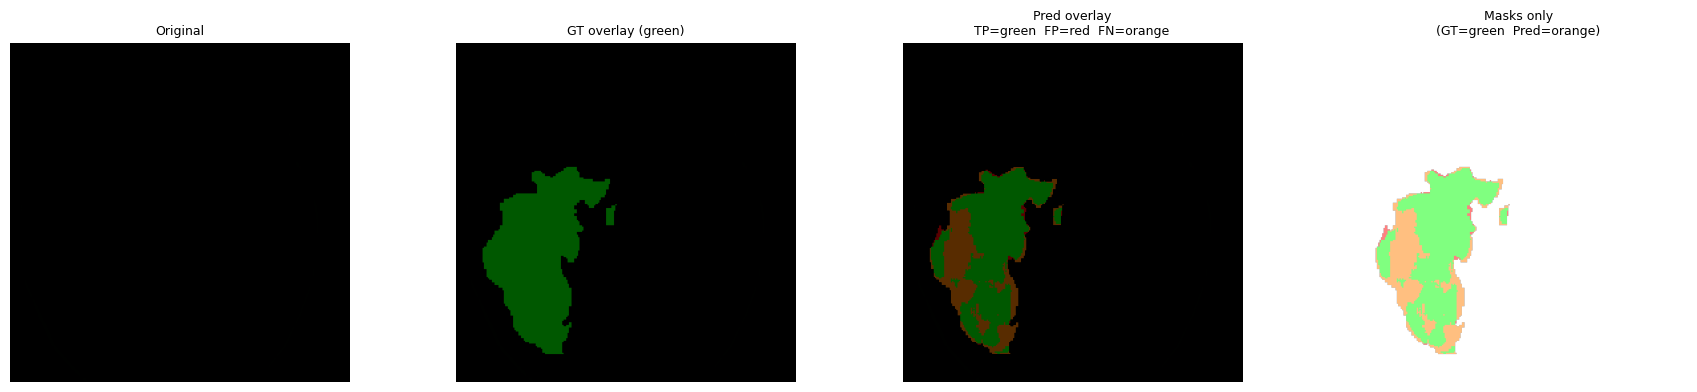

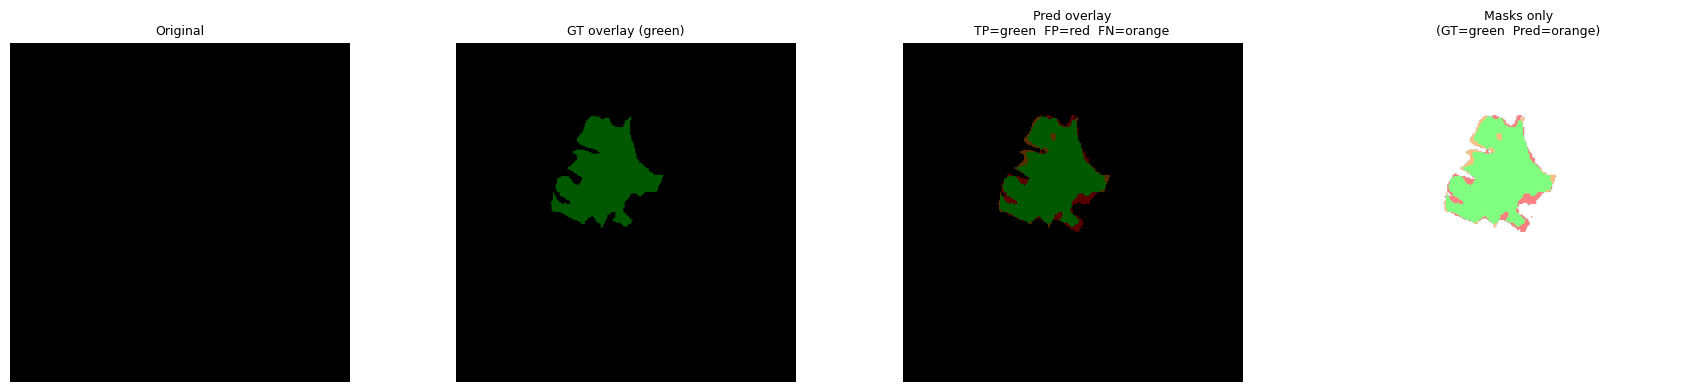

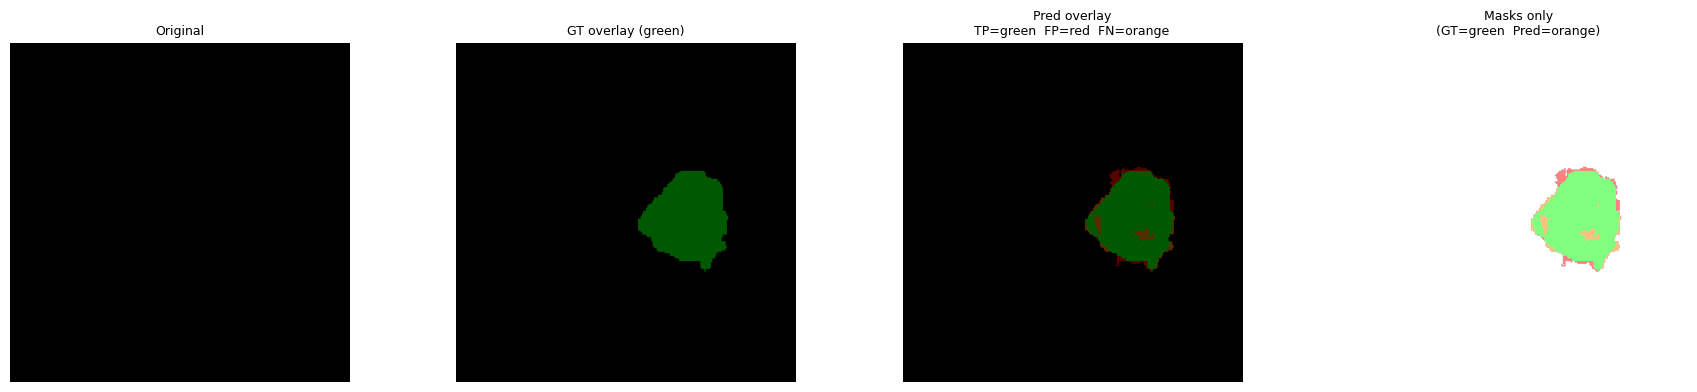

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.79330415].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.79330415].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.79330415].


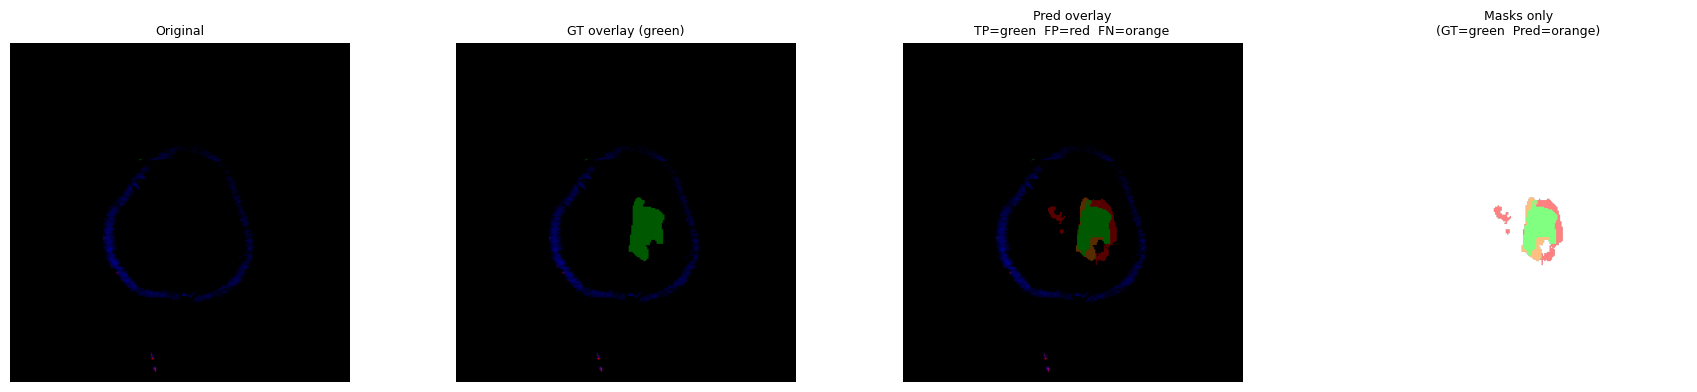

In [ ]:
# Run training with the loaded parameters
device = torch.device('cuda')

train_loader_noaug_baseline, val_loader_noaug_baseline = get_dataloaders(df, val_split=0.15, batch_size=params_noaug_baseline["batch_size"], omit_empty_masks=True, augment=False)

model_noaug_baseline = BaselineUNet()
print("Number of Parameters (Baseline, no augment):", sum(p.numel() for p in model_noaug_baseline.parameters()))
trained_model_noaug_baseline_bce, results_noaug_baseline_bce = train(
    model_noaug_baseline,
    train_loader_noaug_baseline,
    val_loader_noaug_baseline,
    device,
    lr=params_noaug_baseline['lr'],
    optimizer_class=optim.Adam if params_noaug_baseline['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_noaug_baseline['step_size'], "gamma": params_noaug_baseline['gamma']},
    early_stopping=False
)
evaluate(results_noaug_baseline_bce)

[Data] Train images: 1167 ; Val images: 206


Final Test Dice: 0.8378
Final Test IoU : 0.7558


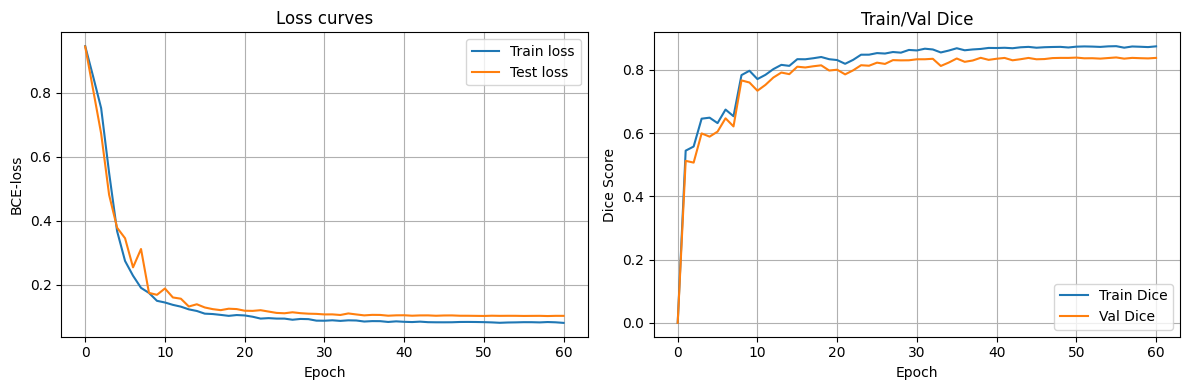

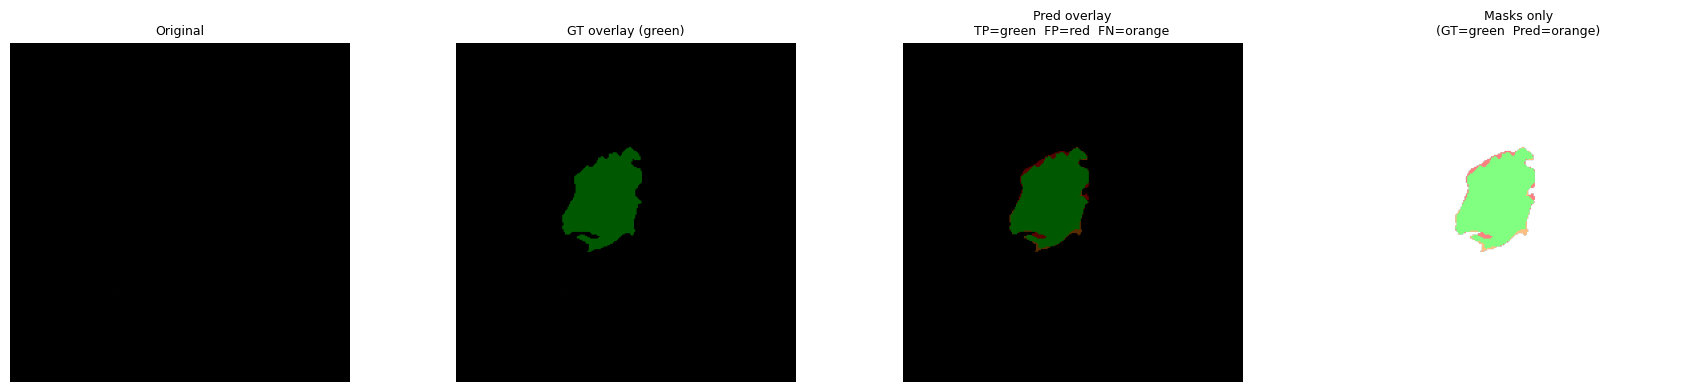

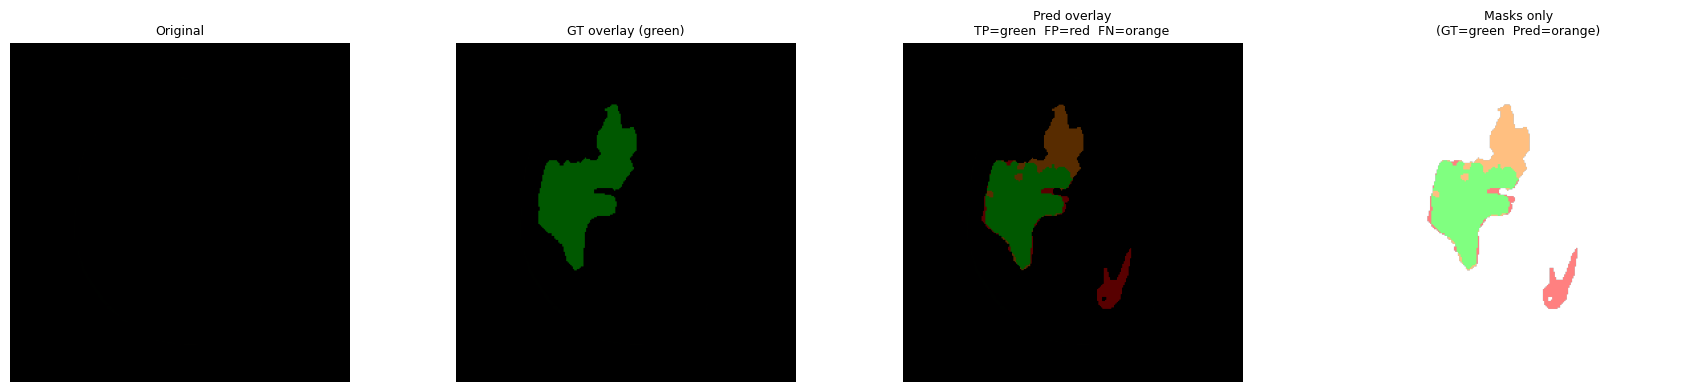

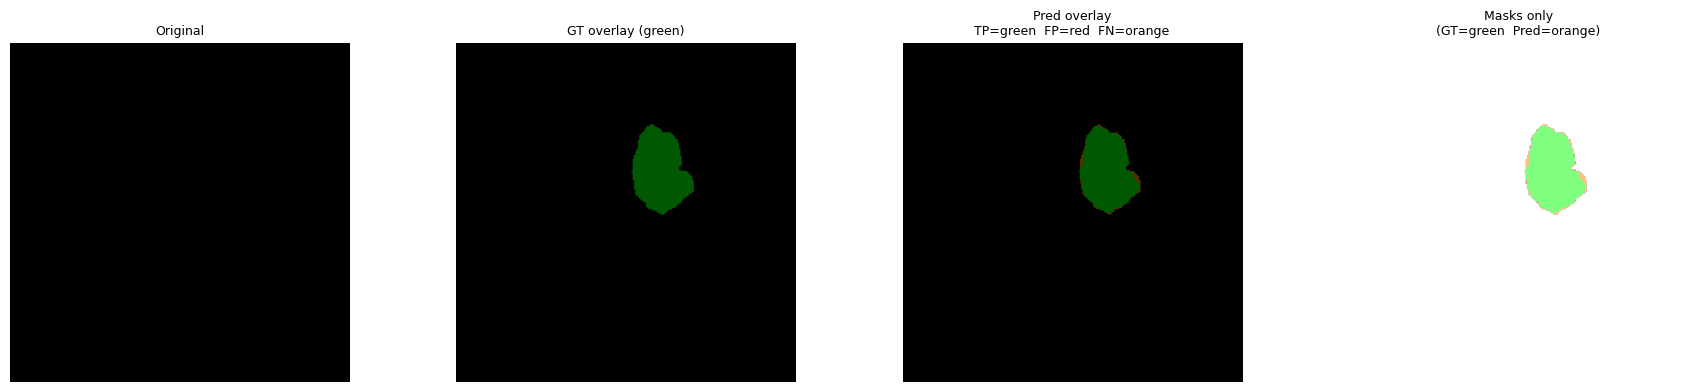

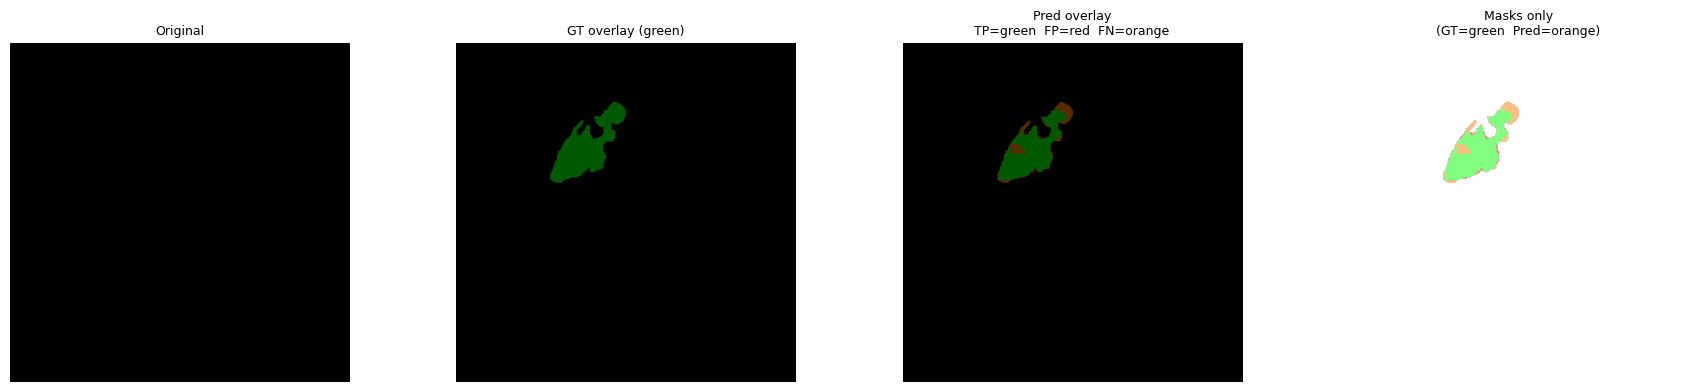

In [ ]:
device = torch.device('cuda')

train_loader_noaug, val_loader_noaug = get_dataloaders(df, val_split=0.15, batch_size=params_noaug_improved["batch_size"], omit_empty_masks=True, augment=False)

model_noaug_improved_dice = ImprovedUNet(num_layers=params_noaug_improved['num_layers'], num_filters=params_noaug_improved['num_filters'])
print("Number of Parameters (Improved UNet, no augment, dice):", sum(p.numel() for p in model_noaug_improved_dice.parameters()))
trained_model_noaug_improved_dice, results_noaug_improved_dice = train(
    model_noaug_improved_dice,
    train_loader_noaug,
    val_loader_noaug,
    device,
    lr=params_noaug_improved['lr'],
    optimizer_class=optim.Adam if params_noaug_improved['optimizer'] == "Adam" else optim.SGD,
    loss_fn=dice_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_noaug_improved['step_size'], "gamma": params_noaug_improved['gamma']},
    early_stopping=False
)
evaluate(results_noaug_improved_dice)

[Data] Train images: 1167 ; Val images: 206


Final Test Dice: 0.8402
Final Test IoU : 0.7590


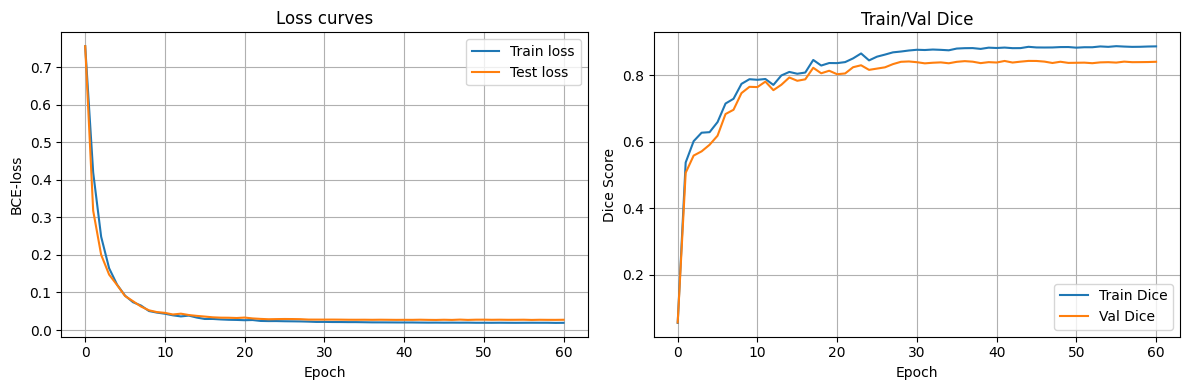

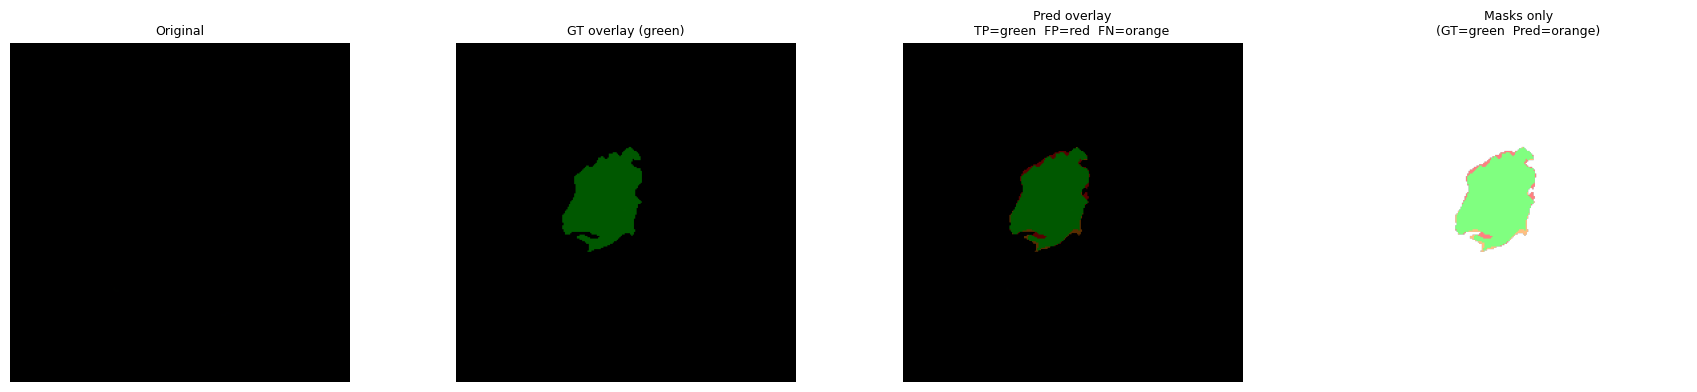

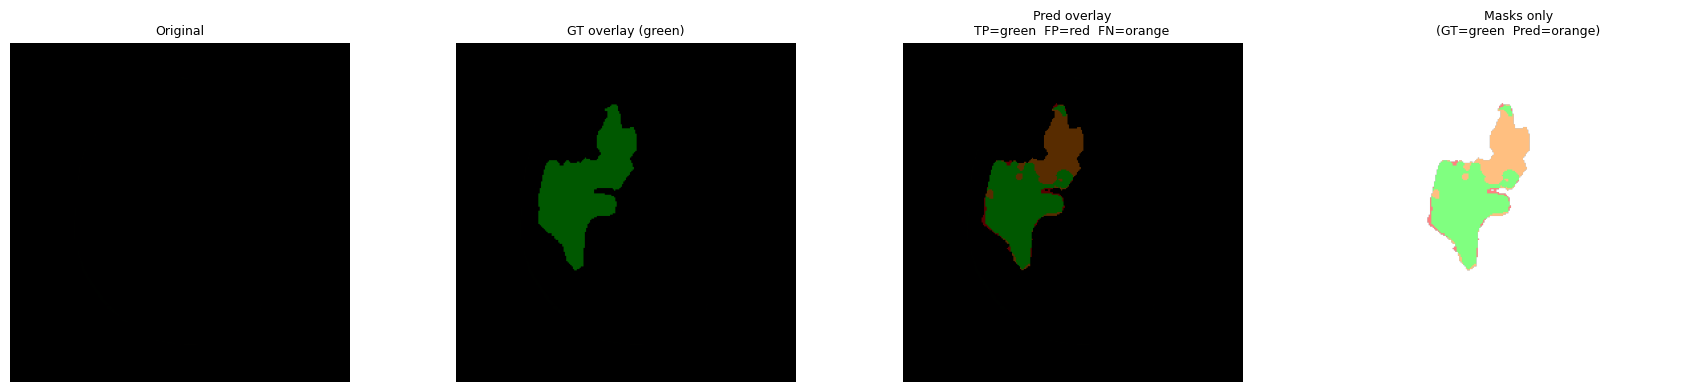

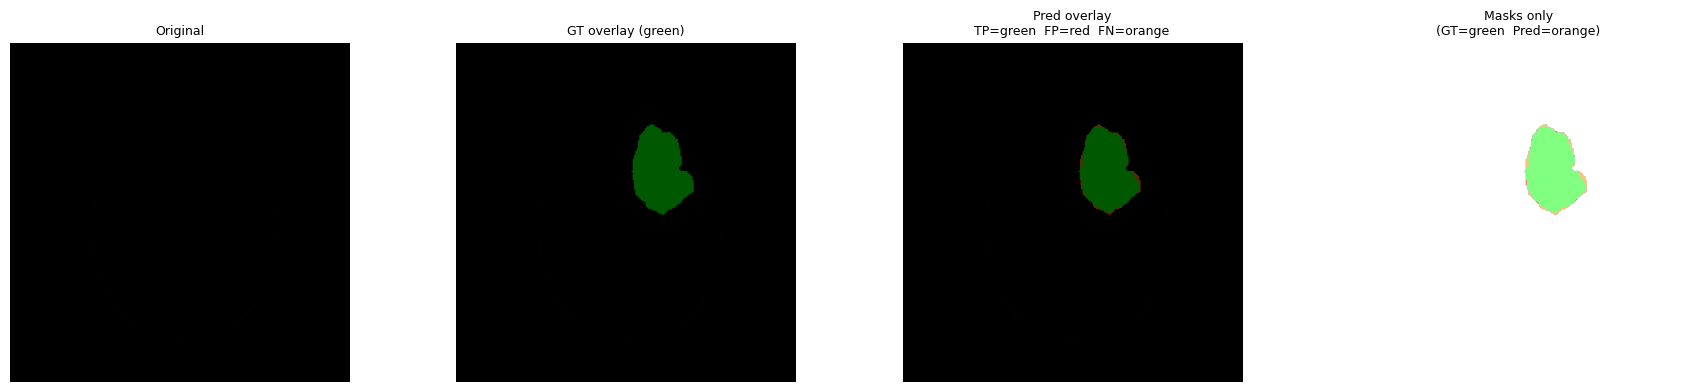

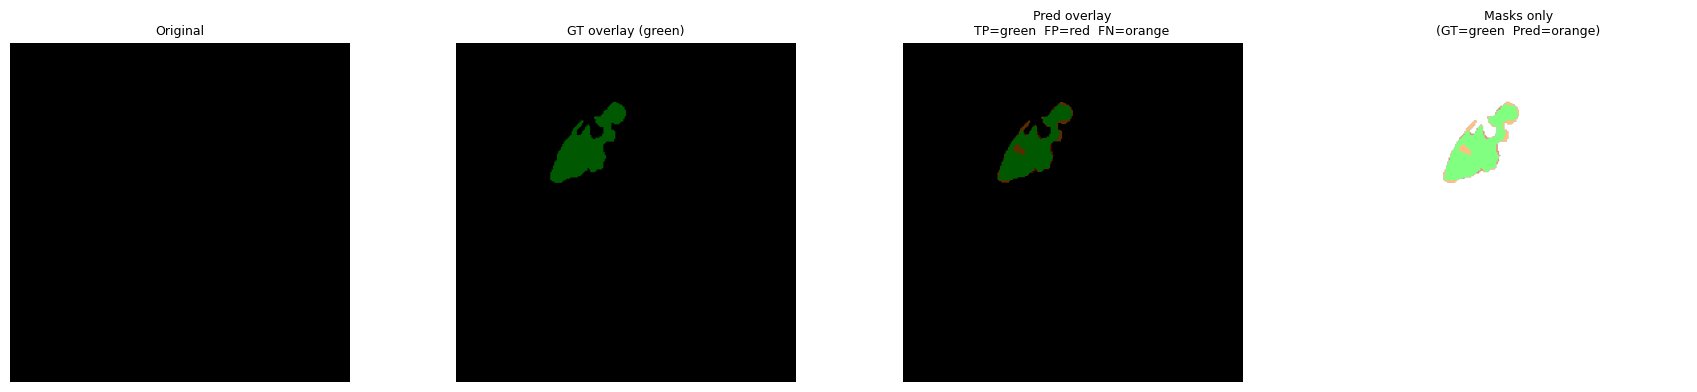

In [27]:
device = torch.device('cuda')

train_loader_noaug, val_loader_noaug = get_dataloaders(df, val_split=0.15, batch_size=params_noaug_improved["batch_size"], omit_empty_masks=True, augment=False)

model_noaug_improved_bce_dice = ImprovedUNet(num_layers=params_noaug_improved['num_layers'], num_filters=params_noaug_improved['num_filters'])
trained_model_noaug_improved_bce_dice, results_noaug_improved_bce_dice = train(
    model_noaug_improved_bce_dice,
    train_loader_noaug,
    val_loader_noaug,
    device,
    lr=params_noaug_improved['lr'],
    optimizer_class=optim.Adam if params_noaug_improved['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_dice_loss,
    epochs=60,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_noaug_improved['step_size'], "gamma": params_noaug_improved['gamma']},
    early_stopping=False
)
evaluate(results_noaug_improved_bce_dice)

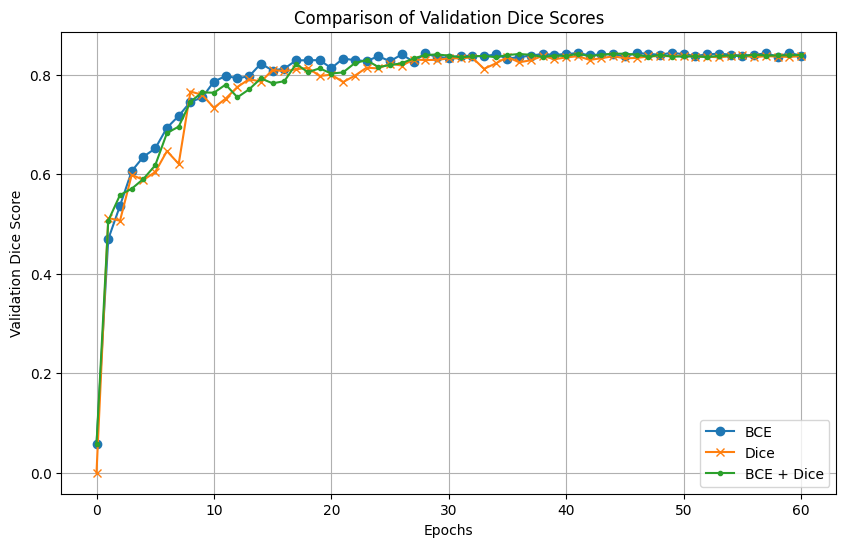

In [28]:
results_list_noaug_losses = [
    results_noaug_improved_bce,
    results_noaug_improved_dice,
    results_noaug_improved_bce_dice
]
losses_list = [
    "BCE",
    "Dice",
    "BCE + Dice"
]
evaluate_losses(results_list_noaug_losses, losses_list)

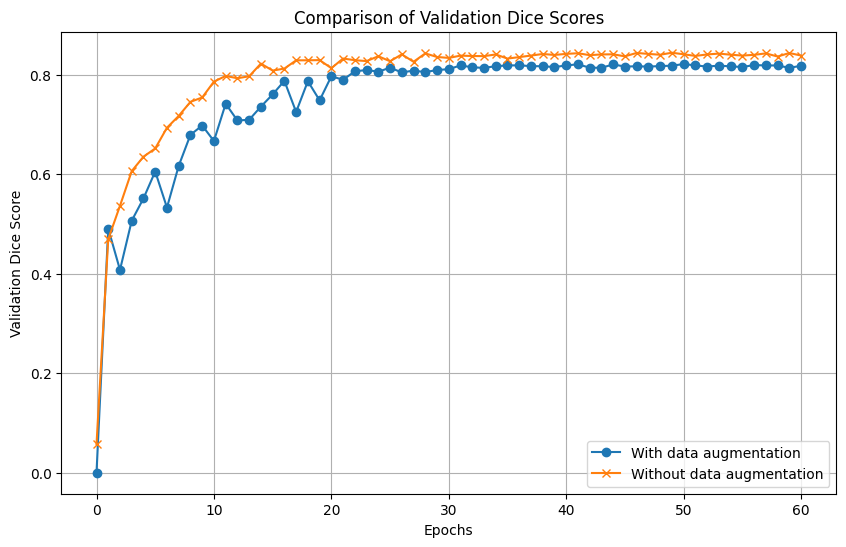

In [ ]:
results_list_augs = [
    results_aug_improved_bce,
    results_noaug_improved_bce,
]
augs_list = [
    "With data augmentation",
    "Without data augmentation",
]
evaluate_losses(results_list_augs, augs_list)

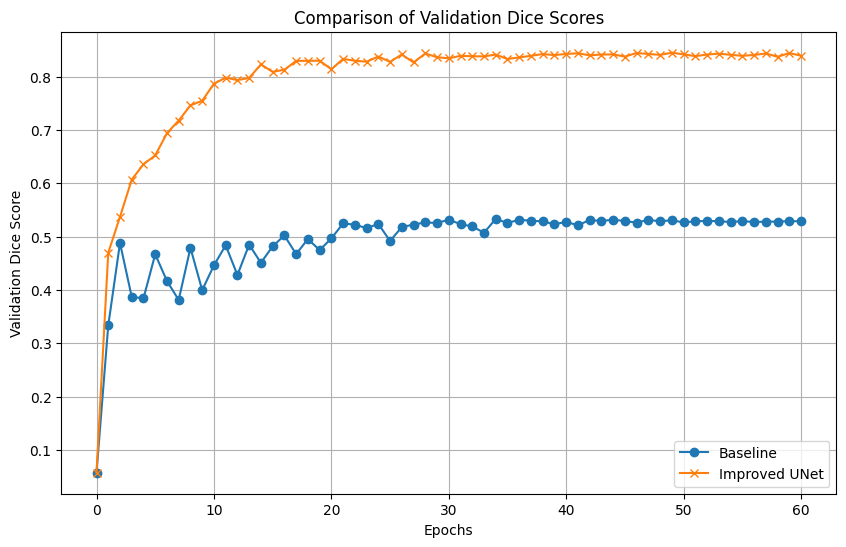

In [24]:
results_list_models = [
    results_noaug_baseline_bce,
    results_noaug_improved_bce,
]
models_list = [
    "Baseline",
    "Improved UNet",
]
evaluate_losses(results_list_models, models_list)